# **Credit Risk Analysis**

### **Import Libraries & Setup**

In [104]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

print("Libraries imported successfully!")

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Libraries imported successfully!
Random seed set to 42


### **Load Dataset**

In [105]:
df = pd.read_csv("credit_risk_dataset.csv")

print("="*30)
print("Dataset Loaded Successfully")
print("="*30)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nFirst 5 Rows")
display(df.head())

Dataset Loaded Successfully
Rows    : 32,581
Columns : 12

First 5 Rows


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [106]:
print("=" * 20)
print("DATASET INFORMATION")
print("=" * 20)

df.info()

print("\nData Types")
display(df.dtypes.to_frame(name="Data Type"))

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

Data Types

,Data Type
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


### **Data Quality Check**

### Missing Values

In [107]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values("Missing Values", ascending=False)

print("=" * 15)
print("MISSING VALUES")
print("=" * 15)

display(missing)

print("\nColumns with Missing Values:")

display(missing[missing["Missing Values"] > 0])

MISSING VALUES


,Missing Values,Percentage (%)
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_income,0,0.00
person_age,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00



Columns with Missing Values:


,Missing Values,Percentage (%)
loan_int_rate,3116,9.56
person_emp_length,895,2.75


### Duplicate Check

In [108]:
duplicate_count = df.duplicated().sum()

print("=" * 20)
print("DUPLICATE RECORDS")
print("=" * 20)

print(f"Total Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    duplicate_percentage = (duplicate_count / len(df)) * 100
    print(f"Percentage of Dataset: {duplicate_percentage:.2f}%")

    print("\nFirst 5 Duplicate Records:")
    display(df[df.duplicated()].head())
else:
    print("No duplicate records found.")

DUPLICATE RECORDS
Total Duplicate Rows: 165
Percentage of Dataset: 0.51%

First 5 Duplicate Records:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,N,4
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,N,3
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,N,4
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,N,4


### Statistical Summary of Numerical Features

In [109]:
print("=" * 40)
print("STATISTICAL SUMMARY - NUMERICAL FEATURES")
print("=" * 40)

display(df.describe().T)

STATISTICAL SUMMARY - NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


### Statistical Summary of Categorical Features

In [110]:
print("=" * 50)
print("STATISTICAL SUMMARY - CATEGORICAL FEATURES")
print("=" * 50)

display(df.describe(include='object').T)

STATISTICAL SUMMARY - CATEGORICAL FEATURES


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


### **Exploratory Data Analysis (EDA)**

### Target Variable Distribution

LOAN STATUS DISTRIBUTION


,Count,Percentage (%)
loan_status,,
0,25473,78.18
1,7108,21.82


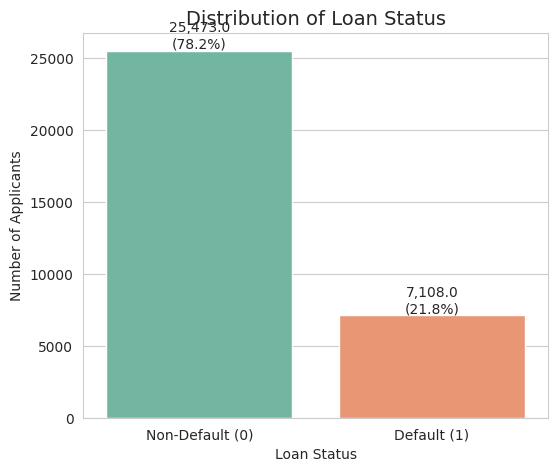

In [111]:
target_counts = df["loan_status"].value_counts().sort_index()
target_percent = (target_counts / len(df) * 100).round(2)

print("=" * 30)
print("LOAN STATUS DISTRIBUTION")
print("=" * 30)

summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percent
})

display(summary)

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="loan_status",
    palette="Set2"
)

plt.title("Distribution of Loan Status", fontsize=14)
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.xticks([0,1], ["Non-Default (0)", "Default (1)"])

for p in ax.patches:
    height = p.get_height()
    percentage = height / len(df) * 100

    ax.annotate(
        f"{height:,}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width()/2, height),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

### Distribution of Numerical Features

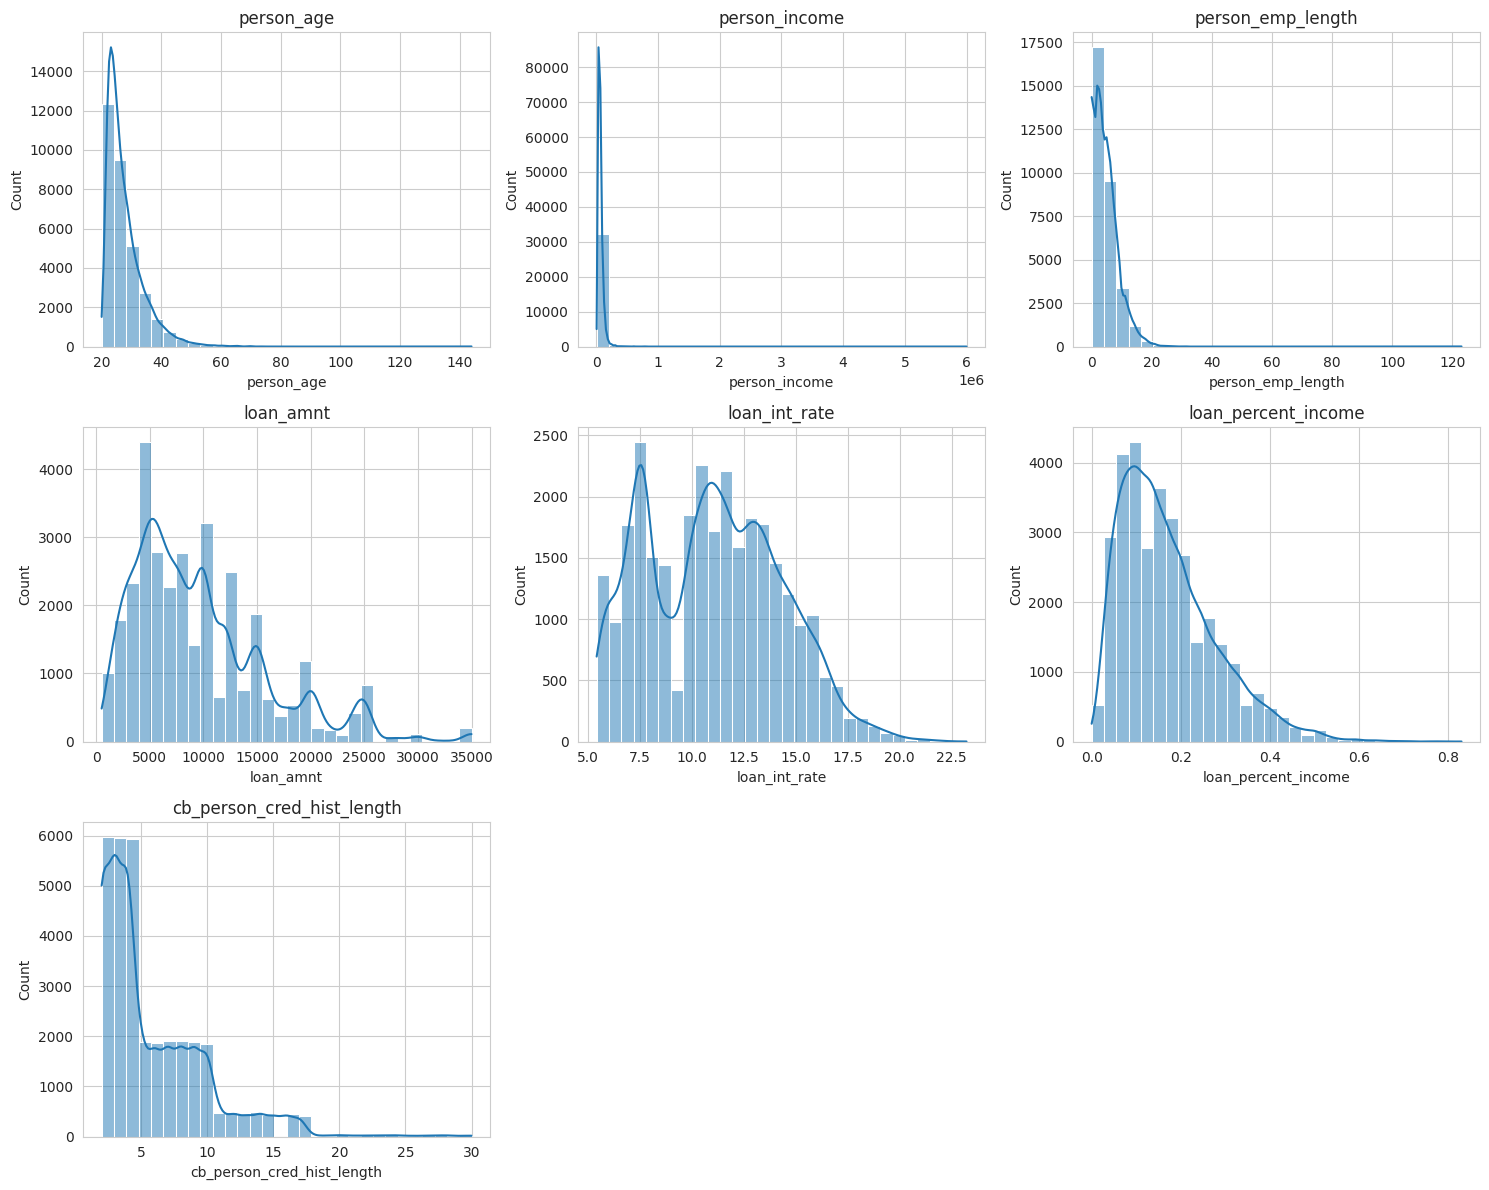

In [112]:
num_cols = df.select_dtypes(include=np.number).columns.drop("loan_status")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplots of Numerical Features

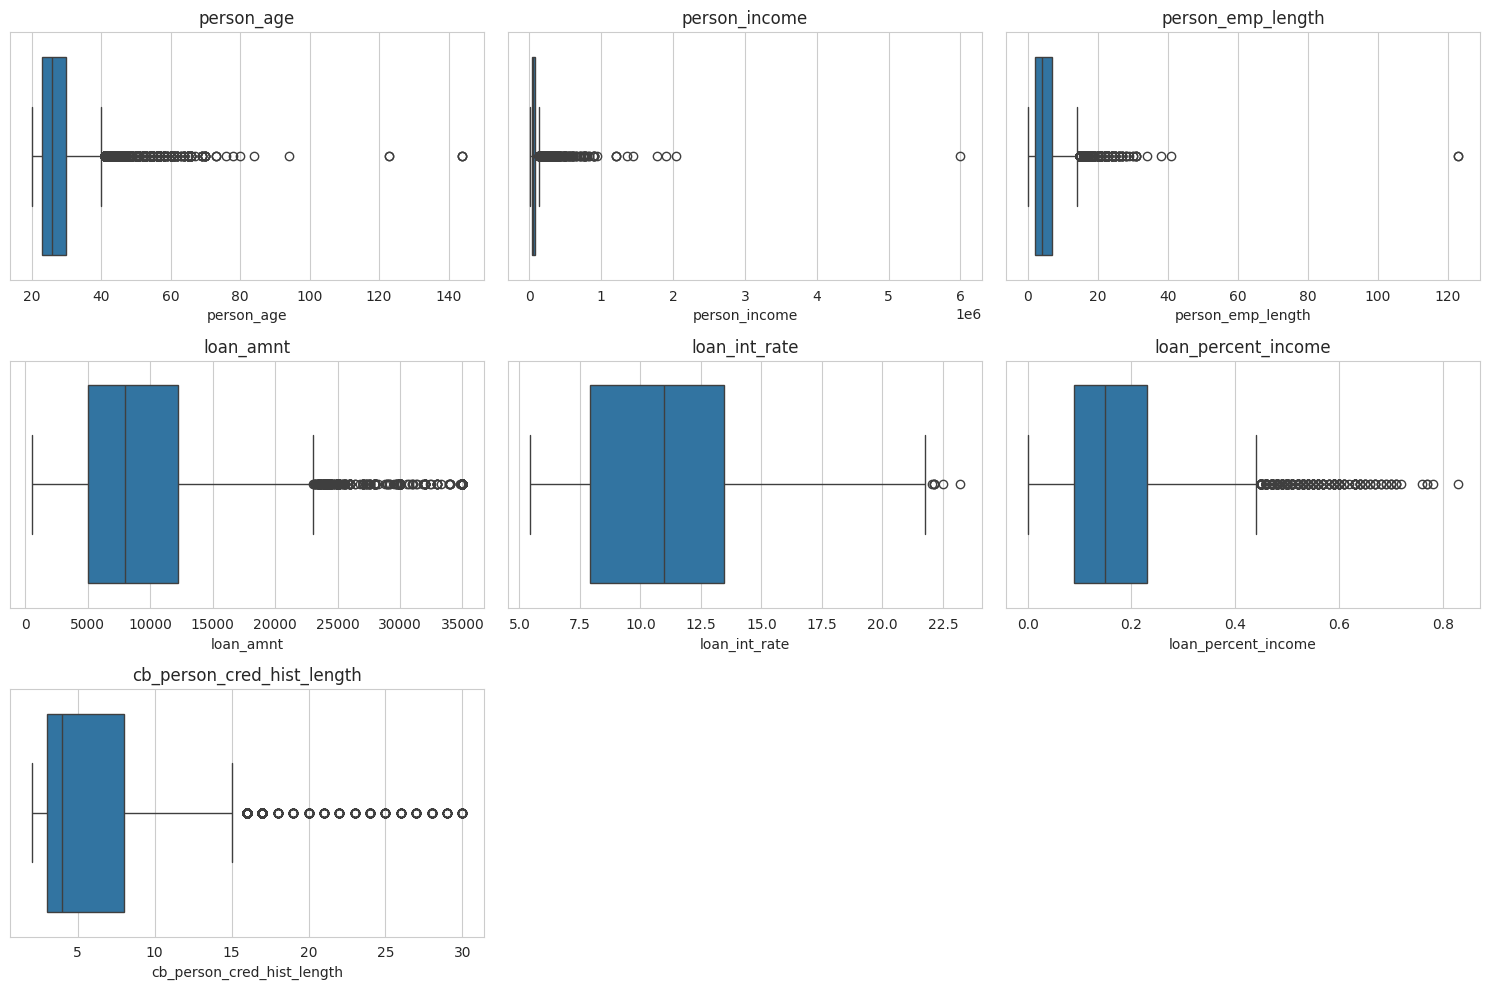

In [113]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Distribution of Categorical Features

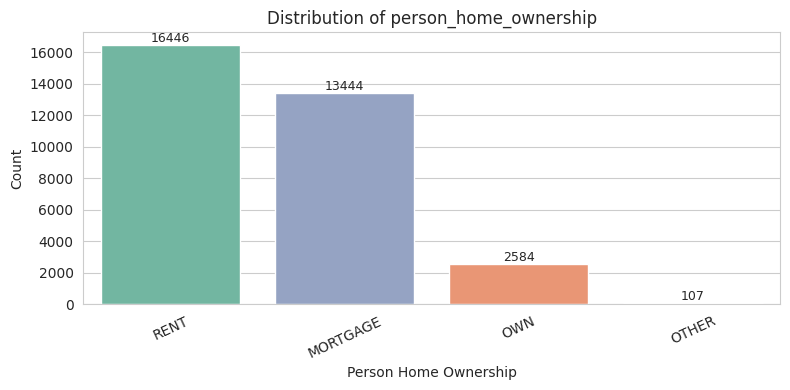

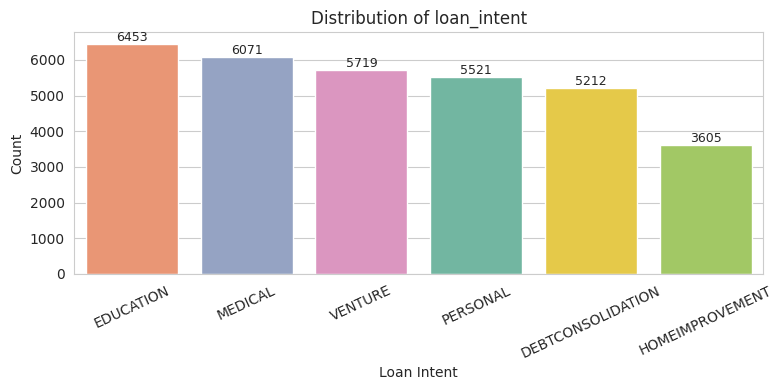

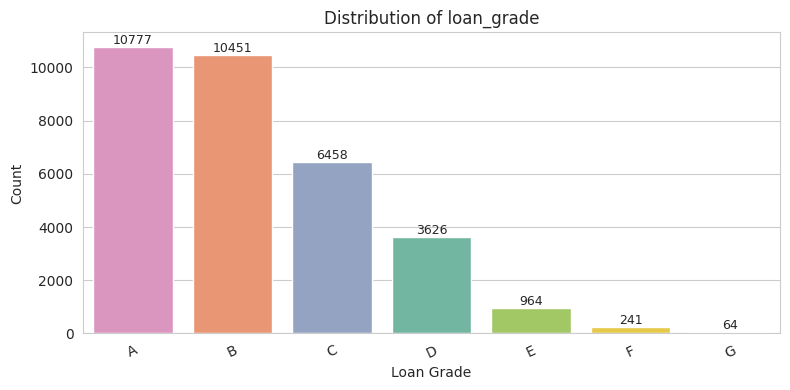

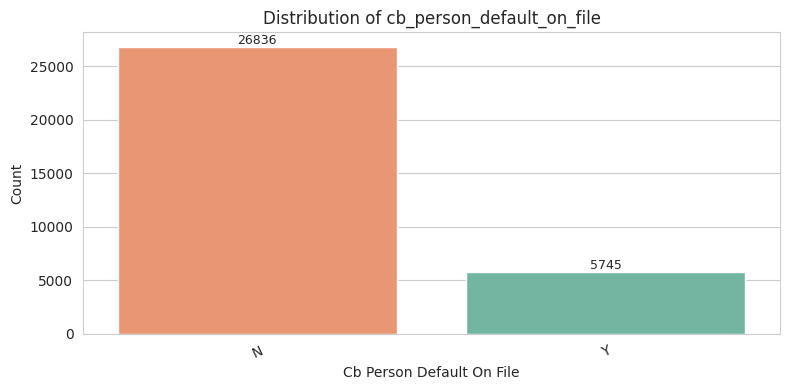

In [114]:
cat_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for col in cat_cols:

    plt.figure(figsize=(8,4))

    order = df[col].value_counts().index

    ax = sns.countplot(
        data=df,
        x=col,
        order=order,
        hue=col,
        palette="Set2",
        legend=False
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Count")

    # Add labels
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

### Correlation Heatmap

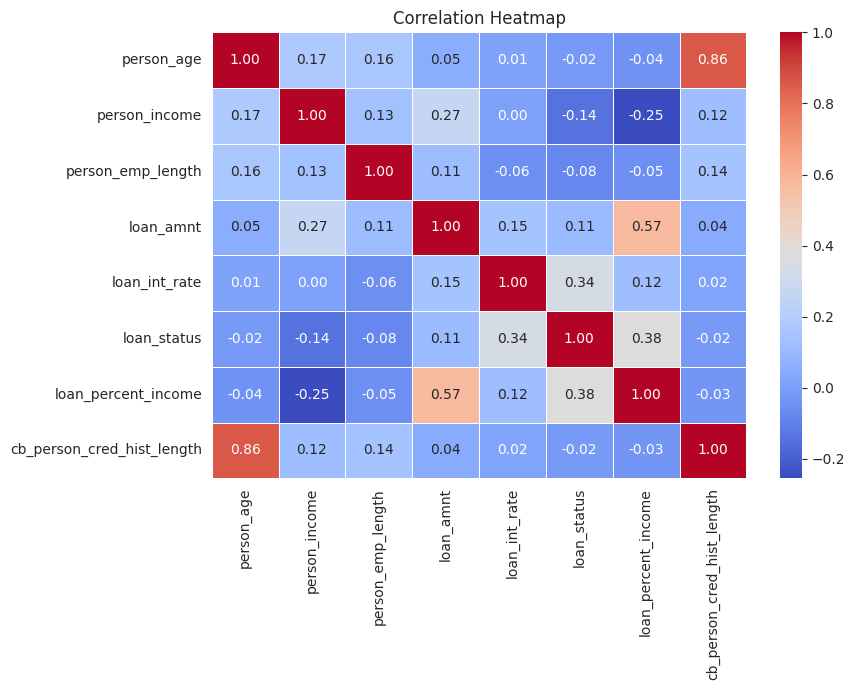

In [115]:
plt.figure(figsize=(9,7))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Default Rate by Categorical Features

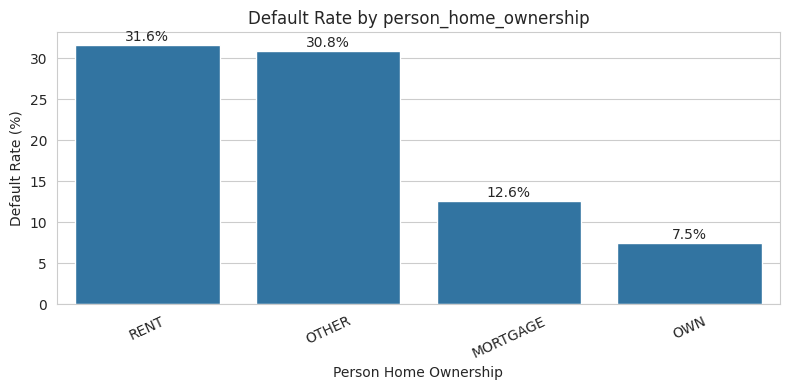

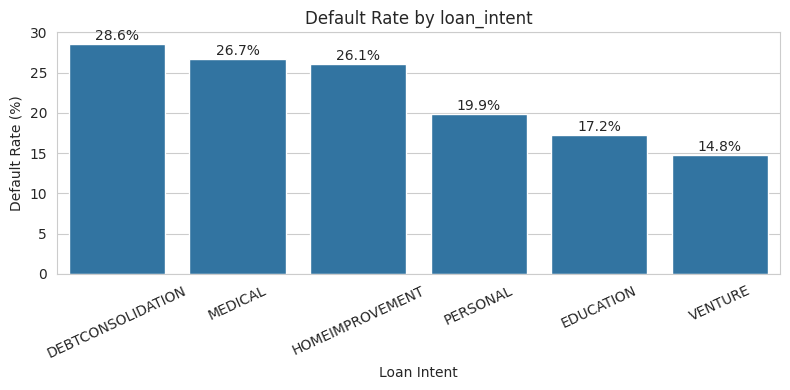

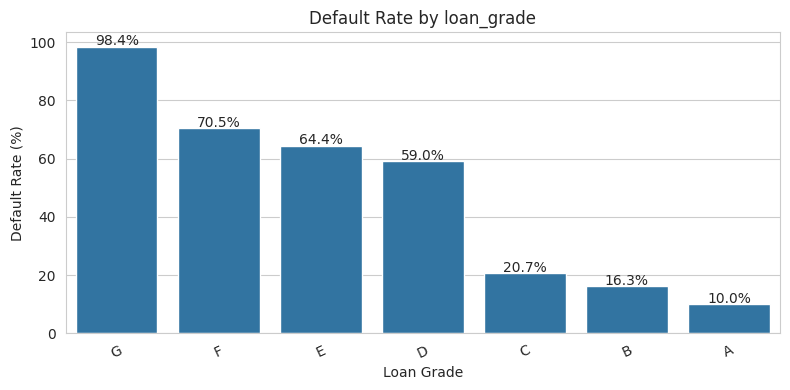

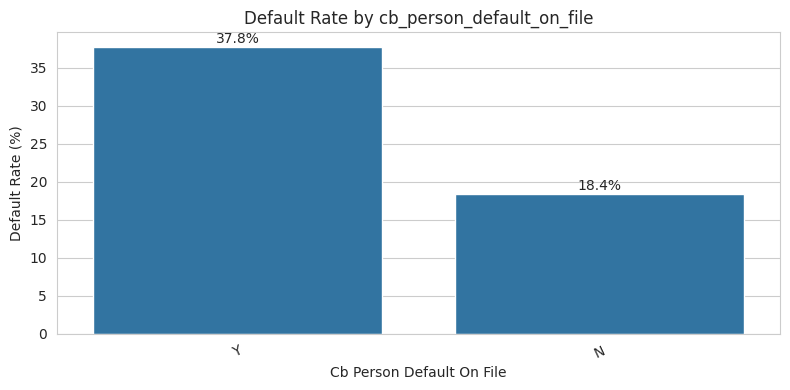

In [116]:
cat_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for col in cat_cols:

    default_rate = (
        df.groupby(col)["loan_status"]
          .mean()
          .sort_values(ascending=False) * 100
    )

    plt.figure(figsize=(8,4))

    ax = sns.barplot(
        x=default_rate.index,
        y=default_rate.values
    )

    plt.title(f"Default Rate by {col}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Default Rate (%)")

    for i, v in enumerate(default_rate.values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

### **Data Preprocessing**

In [117]:
print("Missing Values Before Imputation")
display(df.isnull().sum())

missing_cols = ["person_emp_length", "loan_int_rate"]

for col in missing_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

print("\nMissing Values After Imputation")
display(df.isnull().sum())

Missing Values Before Imputation


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0



Missing Values After Imputation


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


### Handling Missing Values

In [118]:
df_clean = df.copy()

df_clean = df_clean[
    (df_clean["person_age"] >= 18) &
    (df_clean["person_age"] <= 100)
]

df_clean = df_clean[df_clean["person_emp_length"] >= 0]

df_clean = df_clean[
    df_clean["person_emp_length"] <= (df_clean["person_age"] - 15)
]

print("Dataset Shape After Cleaning:", df_clean.shape)

Dataset Shape After Cleaning: (32574, 12)


### Feature Engineering

In [119]:
df_clean["person_income_log"] = np.log1p(df_clean["person_income"])

print("New Feature Added:")
print("person_income_log")

display(
    df_clean[
        ["person_income", "person_income_log"]
    ].head()
)

New Feature Added:
person_income_log


,person_income,person_income_log
1,9600,9.169623
2,9600,9.169623
3,65500,11.089821
4,54400,10.904138
5,9900,9.200391


### Encoding Categorical Variables

In [120]:
df_model = df_clean.copy()

grade_mapping = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7
}

df_model["loan_grade"] = (
    df_model["loan_grade"]
    .str.strip()
    .str.upper()
    .map(grade_mapping)
)

df_model["cb_person_default_on_file"] = (
    df_model["cb_person_default_on_file"]
    .map({"N": 0, "Y": 1})
)

df_model = pd.get_dummies(
    df_model,
    columns=[
        "person_home_ownership",
        "loan_intent"
    ],
    drop_first=True,
    dtype=int
)

print("Encoding Completed Successfully!")

print("\nDataset Shape:", df_model.shape)

display(df_model.head())

Encoding Completed Successfully!

Dataset Shape: (32574, 19)


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_income_log,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21,9600,5.0,2,1000,11.14,0,0.10,0,2,9.169623,0,1,0,1,0,0,0,0
2,25,9600,1.0,3,5500,12.87,1,0.57,0,3,9.169623,0,0,0,0,0,1,0,0
3,23,65500,4.0,3,35000,15.23,1,0.53,0,2,11.089821,0,0,1,0,0,1,0,0
4,24,54400,8.0,3,35000,14.27,1,0.55,1,4,10.904138,0,0,1,0,0,1,0,0
5,21,9900,2.0,1,2500,7.14,1,0.25,0,2,9.200391,0,1,0,0,0,0,0,1


### Prepare Features (X) and Target (y)

In [121]:
model_data = df_model.copy()

model_data = model_data.drop(columns=["person_income"])

X = model_data.drop(columns=["loan_status"])

y = model_data["loan_status"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

print("\nFeatures:")
print(list(X.columns))

Feature Matrix Shape : (32574, 17)
Target Shape         : (32574,)

Features:
['person_age', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_income_log', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


### Train-Test Split

In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training Set")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Set")
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nTraining Class Distribution (%)")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Class Distribution (%)")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Set
X_train: (26059, 17)
y_train: (26059,)

Testing Set
X_test : (6515, 17)
y_test : (6515,)

Training Class Distribution (%)
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64

Testing Class Distribution (%)
loan_status
0    78.19
1    21.81
Name: proportion, dtype: float64


### Feature Scaling

In [123]:
from sklearn.preprocessing import StandardScaler

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Features:")
print(numerical_cols.tolist())

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

print("\nFeature scaling completed successfully!")

Numerical Features:
['person_age', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_income_log', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']

Feature scaling completed successfully!


In [124]:
scaled_summary = pd.DataFrame({
    "Mean": X_train_scaled[numerical_cols].mean().round(2),
    "Std Dev": X_train_scaled[numerical_cols].std().round(2)
})

display(scaled_summary)

,Mean,Std Dev
person_age,0.0,1.0
person_emp_length,0.0,1.0
loan_grade,0.0,1.0
loan_amnt,-0.0,1.0
loan_int_rate,-0.0,1.0
loan_percent_income,-0.0,1.0
cb_person_default_on_file,0.0,1.0
cb_person_cred_hist_length,0.0,1.0
person_income_log,-0.0,1.0
person_home_ownership_OTHER,0.0,1.0


### **Model Building**

### Model Evaluation Function

In [125]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

results = []

def evaluate_model(model, X_test, y_test, y_pred, y_prob, model_name):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("=" * 20)
    print(model_name)
    print("=" * 20)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=1,
        linecolor="black",
        xticklabels=["Non-Default", "Default"],
        yticklabels=["Non-Default", "Default"],
        annot_kws={"size": 12}
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

### **Logistic Regression**

Logistic Regression
Accuracy : 0.8533
Precision: 0.7346
Recall   : 0.5123
F1 Score : 0.6036
ROC-AUC  : 0.8597

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      5094
           1       0.73      0.51      0.60      1421

    accuracy                           0.85      6515
   macro avg       0.80      0.73      0.76      6515
weighted avg       0.84      0.85      0.84      6515



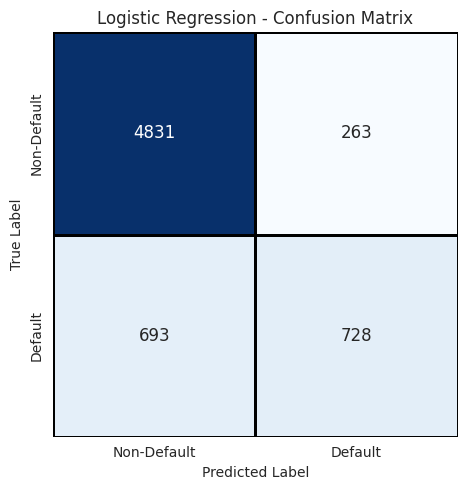

In [126]:
lr = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

evaluate_model(
    model=lr,
    X_test=X_test_scaled,
    y_test=y_test,
    y_pred=y_pred_lr,
    y_prob=y_prob_lr,
    model_name="Logistic Regression"
)

### **Decision Tree**

Decision Tree
Accuracy : 0.9102
Precision: 0.9553
Recall   : 0.6172
F1 Score : 0.7499
ROC-AUC  : 0.8836

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.99      0.95      5094
           1       0.96      0.62      0.75      1421

    accuracy                           0.91      6515
   macro avg       0.93      0.80      0.85      6515
weighted avg       0.91      0.91      0.90      6515



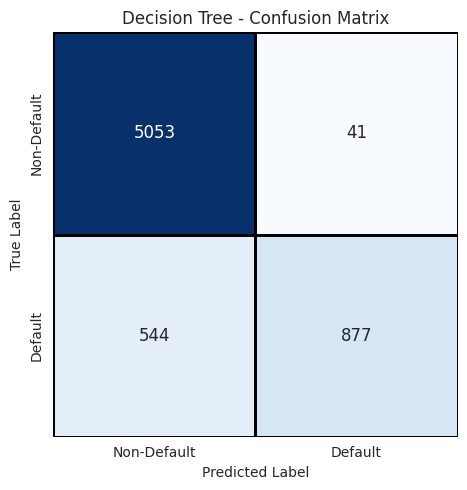

In [127]:
dt = DecisionTreeClassifier(
    random_state=SEED,
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

evaluate_model(
    dt,
    X_test,
    y_test,
    y_pred_dt,
    y_prob_dt,
    "Decision Tree"
)

### **Random Forest**

Random Forest
Accuracy : 0.9337
Precision: 0.9759
Recall   : 0.7136
F1 Score : 0.8244
ROC-AUC  : 0.9306

Classification Report

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5094
           1       0.98      0.71      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.95      0.85      0.89      6515
weighted avg       0.94      0.93      0.93      6515



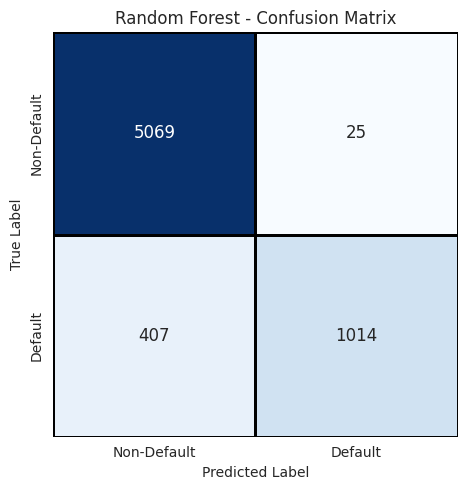

In [128]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

evaluate_model(
    model=rf,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred_rf,
    y_prob=y_prob_rf,
    model_name="Random Forest"
)

### Feature Importance (Random Forest)

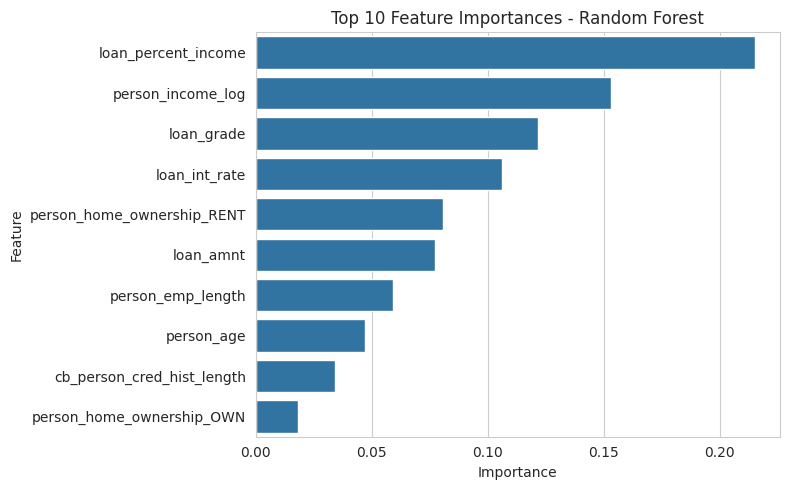

,Feature,Importance
5,loan_percent_income,0.215222
8,person_income_log,0.153095
2,loan_grade,0.121520
4,loan_int_rate,0.105991
11,person_home_ownership_RENT,0.080800
3,loan_amnt,0.077245
1,person_emp_length,0.059177
0,person_age,0.047250
7,cb_person_cred_hist_length,0.034194
10,person_home_ownership_OWN,0.018013


In [132]:
importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_rf,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

display(importance_rf)

### **XGBoost**

XGBoost
Accuracy : 0.9343
Precision: 0.9853
Recall   : 0.7094
F1 Score : 0.8249
ROC-AUC  : 0.9438

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5094
           1       0.99      0.71      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.96      0.85      0.89      6515
weighted avg       0.94      0.93      0.93      6515



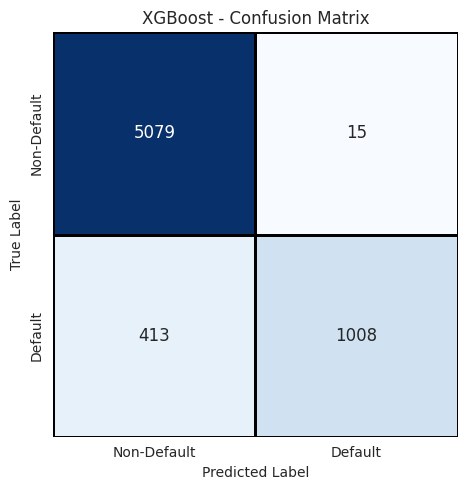

In [129]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEED,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

evaluate_model(
    model=xgb,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred_xgb,
    y_prob=y_prob_xgb,
    model_name="XGBoost"
)

### Feature Importance (XGBoost)

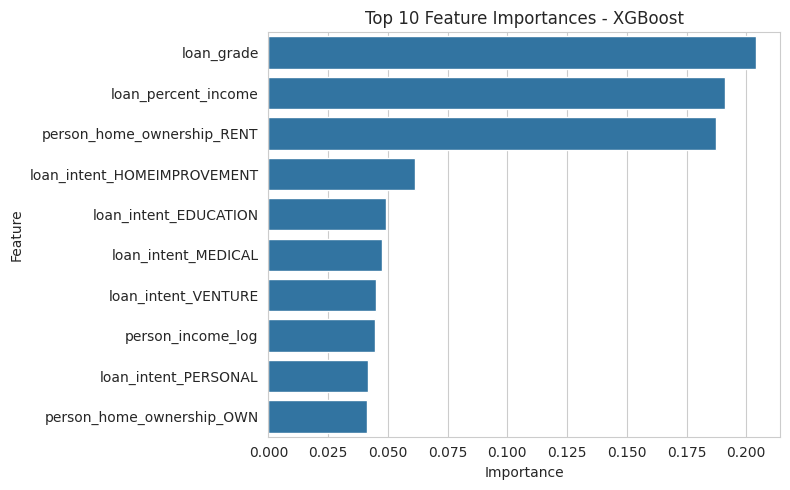

,Feature,Importance
2,loan_grade,0.203926
5,loan_percent_income,0.191030
11,person_home_ownership_RENT,0.187209
13,loan_intent_HOMEIMPROVEMENT,0.061168
12,loan_intent_EDUCATION,0.049015
14,loan_intent_MEDICAL,0.047750
16,loan_intent_VENTURE,0.045157
8,person_income_log,0.044735
15,loan_intent_PERSONAL,0.041585
10,person_home_ownership_OWN,0.041437


In [133]:
importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_xgb,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

display(importance_xgb)

### **Model Comparison**

In [130]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.9343,0.9853,0.7094,0.8249,0.9438
1,Random Forest,0.9337,0.9759,0.7136,0.8244,0.9306
2,Decision Tree,0.9102,0.9553,0.6172,0.7499,0.8836
3,Logistic Regression,0.8533,0.7346,0.5123,0.6036,0.8597


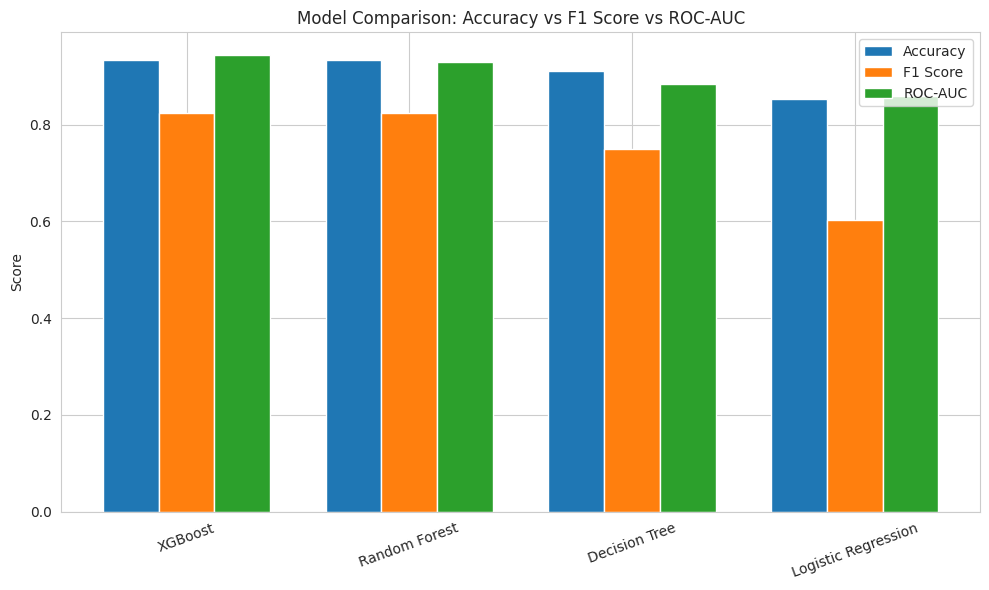

In [134]:
models = results_df["Model"]

accuracy = results_df["Accuracy"]
f1_score = results_df["F1 Score"]
roc_auc = results_df["ROC-AUC"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, f1_score, width, label="F1 Score")
plt.bar(x + width, roc_auc, width, label="ROC-AUC")

plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs F1 Score vs ROC-AUC")
plt.legend()

plt.tight_layout()
plt.show()

### **ROC Curve Comparison**

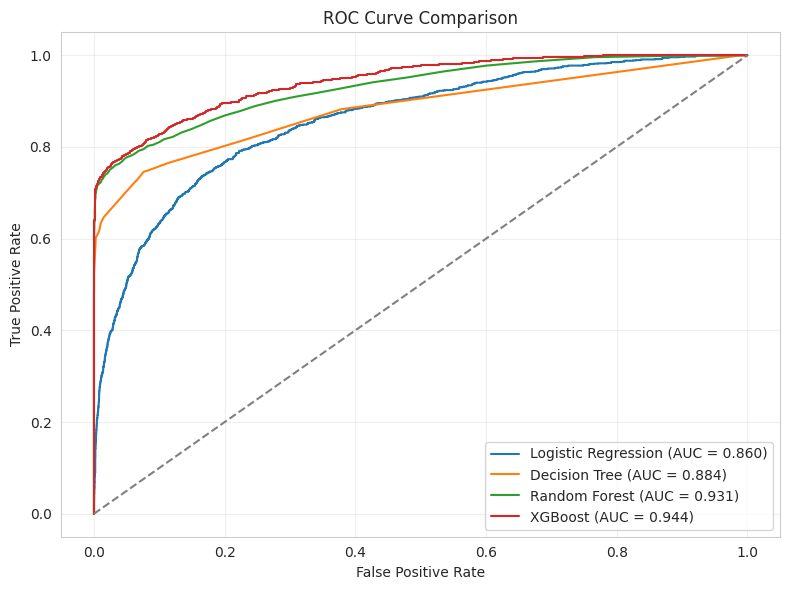

In [131]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Conclusion**

The models were trained and tested on a credit risk dataset to predict whether a borrower will default on a loan or not. Among all the models evaluated, XGBoost performed the best with the highest ROC-AUC and balanced precision-recall performance, making it the most effective model for this classification task. Random Forest also showed strong results, while Logistic Regression and Decision Tree performed comparatively lower. Overall, ensemble models proved to be more reliable for identifying loan default risk.